# WRF Hawaii — 2D Field Plotting

Plots 2D output from WRF history files (`wrf_his_d0X_...nc`) centered on the Hawaiian islands.  
Starts with the coarsest domain (`d01`, 20 km) in `RUN_1996`.

**Total precipitation**: WRF does not store a single `PRECT` variable.  
It stores *accumulated* (from run start) components:
- `RAINC`  — accumulated cumulus precipitation (mm)
- `RAINNC` — accumulated grid-scale precipitation (mm)
- `RAINSH` — accumulated shallow-cumulus precipitation (mm, often zero)

Total accumulated precip = `RAINC + RAINNC + RAINSH`.  
Hourly rate = difference between consecutive time steps of that sum.

In [82]:
import glob
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmocean

In [83]:
from dask.distributed import Client
from dask_jobqueue import PBSCluster

In [84]:
cluster = PBSCluster(
    account="P03010039",
    interface="ext",
    walltime="12:00:00",
    queue="main",
    cores=1,
    memory="8GB",
    processes=4,
    local_directory="/glade/derecho/scratch/rneale/dask-temp",
    log_directory="/glade/derecho/scratch/rneale/dask-logs"
)

cluster.scale(jobs=8)
client = Client(cluster)

client

/glade/u/apps/opt/miniforge/envs/npl-2026a/lib/python3.13/site-packages/distributed/node.py:188: UserWarning: Port 8787 is already in use.
Perhaps you already have a cluster running?
Hosting the HTTP server on port 36897 instead
  warnings.warn(


Connection method: Cluster object,Cluster type: dask_jobqueue.PBSCluster
Dashboard: /node/crhtc84.hpc.ucar.edu/5662/proxy/36897/status,
Dashboard: /node/crhtc84.hpc.ucar.edu/5662/proxy/36897/status,Workers: 0
Total threads: 0,Total memory: 0 B
Comm: tcp://128.117.208.192:34455,Workers: 0
Dashboard: /node/crhtc84.hpc.ucar.edu/5662/proxy/36897/status,Total threads: 0
Started: Just now,Total memory: 0 B


## Configuration

In [85]:
# --- paths & domain ---
DATA_DIR = '/glade/derecho/scratch/hafner/HAWAII/RUN_1996'
DOMAIN   = 'd03'   # d01=coarsest (20 km), d02=medium, d03=finest

# sorted list of all files for this domain
files = sorted(glob.glob(f'{DATA_DIR}/wrf_his_{DOMAIN}_*.nc'))
print(f'Found {len(files)} files for {DOMAIN}')
print('First:', files[0].split('/')[-1])
print('Last: ', files[-1].split('/')[-1])

Found 238 files for d03
First: wrf_his_d03_1995-12-01_00_00_00.nc
Last:  wrf_his_d03_1996-07-25_00_00_00.nc


## Load a single file and inspect

In [86]:
# pick one file to explore
sample_file = files[0]
ds = xr.open_dataset(sample_file)

# decode Times byte array to strings
times = [t.decode() for t in ds['Times'].values]
print('Time steps in file:', times[0], '…', times[-1])
print('Grid (south_north x west_east):', ds.sizes['south_north'], 'x', ds.sizes['west_east'])

# pull lat/lon grids (constant in time, use time=0)
lat = ds['XLAT'].isel(Time=0).values
lon = ds['XLONG'].isel(Time=0).values
print(f'Lat  range: {lat.min():.1f} — {lat.max():.1f}')
print(f'Lon  range: {lon.min():.1f} — {lon.max():.1f}')
print(f'Centre: {ds.attrs["CEN_LAT"]:.2f}N, {ds.attrs["CEN_LON"]:.2f}E')
print(f'DX/DY: {ds.attrs["DX"]/1000:.0f} km')

Time steps in file: 1995-12-01_00:00:00 … 1995-12-01_23:00:00
Grid (south_north x west_east): 175 x 180
Lat  range: 20.8 — 22.1
Lon  range: -158.7 — -157.3
Centre: 21.46N, -158.02E
DX/DY: 1 km


## Plotting helper

In [87]:
def plot_wrf_2d(
    field,          # 2-D numpy array (south_north, west_east)
    lat, lon,       # 2-D coordinate arrays
    title='',
    units='',
    cmap='viridis',
    vmin=None, vmax=None,
    domain=DOMAIN,  # used to auto-select map extent
    extent=None,    # override auto extent if supplied
    figsize=(10, 6),
    add_gridlines=True,
):
    """
    Plot a 2-D WRF field on a Mercator map centred on Hawaii.
    Returns (fig, ax).
    """
    if extent is None:
        extent = {
            'd01': (-170, -148, 16, 27),
            'd02': (-164, -151, 17, 24),
            'd03': (-159, -157, 20.5, 22.5),
        }.get(domain, (-170, -148, 16, 27))

    proj = ccrs.Mercator(central_longitude=-158)
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': proj})

    ax.set_extent(extent, crs=ccrs.PlateCarree())

    # plot field
    pc = ax.pcolormesh(
        lon, lat, field,
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax,
        shading='auto',
    )

    # coastlines & land
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0, alpha=0.4)

    if add_gridlines:
        gl = ax.gridlines(
            crs=ccrs.PlateCarree(), draw_labels=True,
            linewidth=0.5, color='gray', alpha=0.5, linestyle='--',
        )
        gl.top_labels = False
        gl.right_labels = False
        gl.xlocator = mticker.MultipleLocator(4)
        gl.ylocator = mticker.MultipleLocator(2)

    cb = plt.colorbar(pc, ax=ax, orientation='vertical', pad=0.03, shrink=0.85)
    cb.set_label(units)
    ax.set_title(title)

    plt.tight_layout()
    return fig, ax

## Total precipitation

Because `RAINC`/`RAINNC` are **accumulated from model-run start**, we get the hourly rate by differencing consecutive time steps.  
To get the full-day total for a single file (24 h), take `t[-1] − t[0]`.

In [88]:
def total_precip_accum(ds):
    """Accumulated total precip (mm) at each time step in ds."""
    return ds['RAINC'] + ds['RAINNC'] + ds['RAINSH']

def daily_precip(ds):
    """Total precip (mm) over the 24 h period covered by one file."""
    accum = total_precip_accum(ds)
    return (accum.isel(Time=-1) - accum.isel(Time=0)).values

def hourly_precip_rate(ds):
    """Hourly precipitation rate (mm/h) for each hour in the file.
    Returns array of shape (Time-1, south_north, west_east)."""
    accum = total_precip_accum(ds).values   # (Time, ny, nx)
    return np.diff(accum, axis=0)           # already mm per 1-hour step

prec_day = daily_precip(ds)
print(f'Daily precip range: {prec_day.min():.1f} – {prec_day.max():.1f} mm')

Daily precip range: 0.0 – 216.8 mm


## Example plots

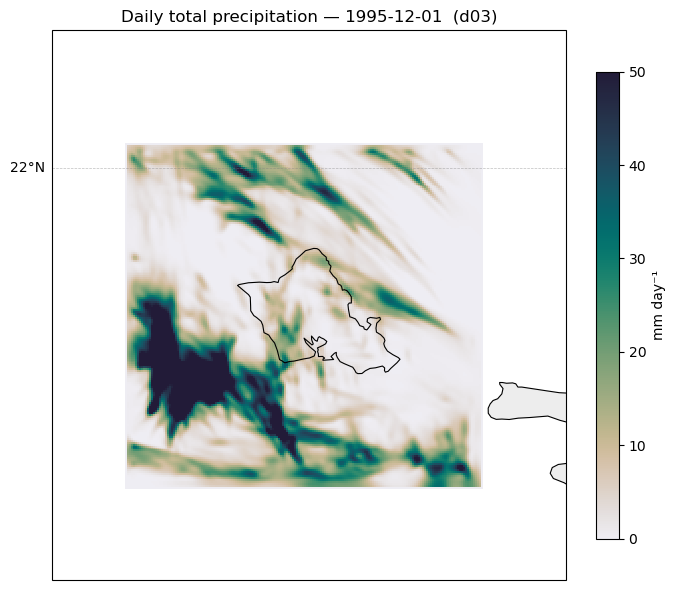

In [89]:
# --- daily total precipitation ---
date_str = times[0][:10]
fig, ax = plot_wrf_2d(
    prec_day, lat, lon,
    title=f'Daily total precipitation — {date_str}  ({DOMAIN})',
    units='mm day⁻¹',
    cmap=cmocean.cm.rain,
    vmin=0, vmax=50,
)
plt.show()

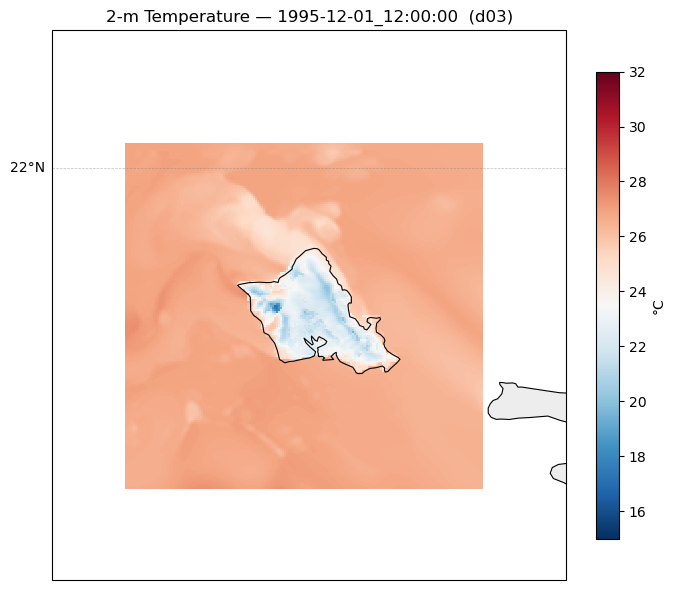

In [90]:
# --- 2-m temperature at a single hour ---
t_idx = 12   # 12 UTC
t2 = ds['T2'].isel(Time=t_idx).values - 273.15   # K → °C
fig, ax = plot_wrf_2d(
    t2, lat, lon,
    title=f'2-m Temperature — {times[t_idx]}  ({DOMAIN})',
    units='°C',
    cmap='RdBu_r',
    vmin=15, vmax=32,
)
plt.show()

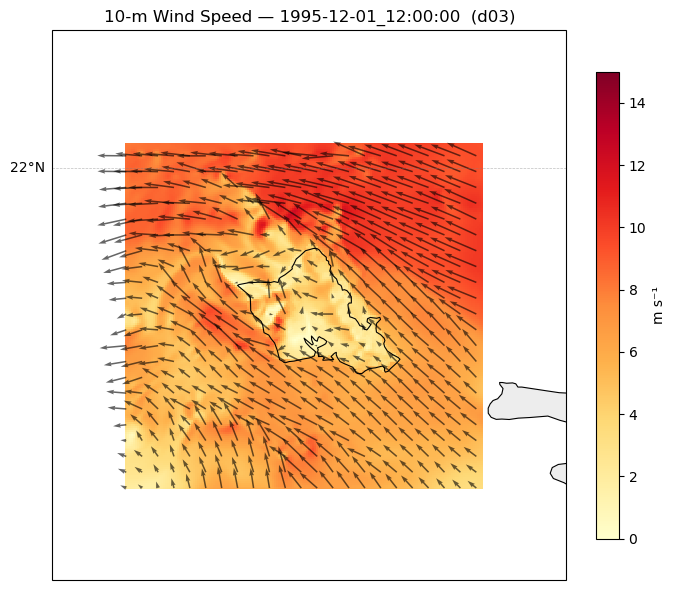

In [91]:
# --- 10-m wind speed ---
u10 = ds['U10'].isel(Time=t_idx).values
v10 = ds['V10'].isel(Time=t_idx).values
spd = np.sqrt(u10**2 + v10**2)

fig, ax = plot_wrf_2d(
    spd, lat, lon,
    title=f'10-m Wind Speed — {times[t_idx]}  ({DOMAIN})',
    units='m s⁻¹',
    cmap='YlOrRd',
    vmin=0, vmax=15,
)

# add wind vectors (subsample to avoid clutter)
skip = 8
ax.quiver(
    lon[::skip, ::skip], lat[::skip, ::skip],
    u10[::skip, ::skip], v10[::skip, ::skip],
    transform=ccrs.PlateCarree(),
    scale=150, width=0.003, color='k', alpha=0.6,
)
plt.show()

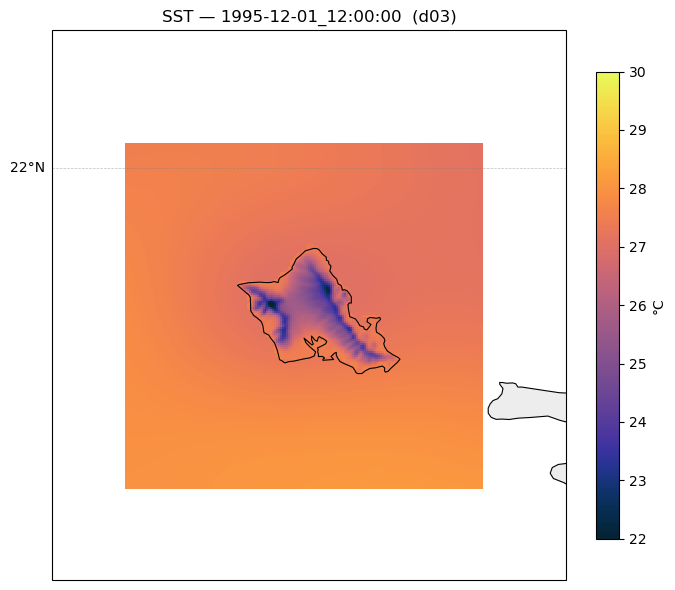

In [92]:
# --- sea-surface temperature ---
sst = ds['SST'].isel(Time=t_idx).values
sst_masked = np.where(sst < 200, np.nan, sst - 273.15)   # mask land fill values

fig, ax = plot_wrf_2d(
    sst_masked, lat, lon,
    title=f'SST — {times[t_idx]}  ({DOMAIN})',
    units='°C',
    cmap=cmocean.cm.thermal,
    vmin=22, vmax=30,
)
plt.show()

## Animation

`animate_wrf_2d` works like `plot_wrf_2d` but takes a 3-D array `(Time, ny, nx)` and returns a `FuncAnimation`.  
Displayed inline with `HTML(anim.to_jshtml())`.

In [93]:
from matplotlib.animation import FuncAnimation
from IPython.display import HTML


def animate_wrf_2d(
    field_3d,      # (Time, ny, nx) numpy array
    lat, lon,
    times_list,    # list of time-label strings, one per frame
    title_base='',
    units='',
    cmap='viridis',
    vmin=None, vmax=None,
    domain=DOMAIN,
    extent=None,
    figsize=(10, 6),
    interval=400,  # ms between frames
):
    """
    Animate a sequence of 2-D WRF fields on a Hawaii-centred Mercator map.
    Returns a matplotlib FuncAnimation — display with HTML(anim.to_jshtml()).
    """
    if extent is None:
        extent = {
            'd01': (-170, -148, 16, 27),
            'd02': (-164, -151, 17, 24),
            'd03': (-159, -157, 20.5, 22.5),
        }.get(domain, (-170, -148, 16, 27))

    if vmin is None:
        vmin = np.nanmin(field_3d)
    if vmax is None:
        vmax = np.nanmax(field_3d)

    proj = ccrs.Mercator(central_longitude=-158)
    fig, ax = plt.subplots(figsize=figsize, subplot_kw={'projection': proj})
    ax.set_extent(extent, crs=ccrs.PlateCarree())
    ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
    ax.add_feature(cfeature.LAND, facecolor='lightgray', zorder=0, alpha=0.4)

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(), draw_labels=True,
        linewidth=0.5, color='gray', alpha=0.5, linestyle='--',
    )
    gl.top_labels = False
    gl.right_labels = False
    gl.xlocator = mticker.MultipleLocator(4)
    gl.ylocator = mticker.MultipleLocator(2)

    pc = ax.pcolormesh(
        lon, lat, field_3d[0],
        transform=ccrs.PlateCarree(),
        cmap=cmap, vmin=vmin, vmax=vmax, shading='auto',
    )
    cb = plt.colorbar(pc, ax=ax, orientation='vertical', pad=0.03, shrink=0.85)
    cb.set_label(units)
    ttl = ax.set_title(f'{title_base} — {times_list[0]}')

    def update(frame):
        pc.set_array(field_3d[frame].ravel())
        ttl.set_text(f'{title_base} — {times_list[frame]}')
        return pc, ttl

    anim = FuncAnimation(fig, update, frames=len(times_list), interval=interval, blit=False)
    plt.close(fig)
    return anim

In [104]:
# shared setup — use the already-loaded single-day dataset and times list
times = [t.decode() for t in ds['Times'].values]

# subsample to every 3 hours (8 frames) to keep the animation snappy
frame_idx = list(range(0, 24, 3))

In [105]:
# --- animate hourly precipitation rate ---
prec_hourly = hourly_precip_rate(ds)   # (23, ny, nx)
# align frames: rate in hour N covers times[N] → times[N+1], label as end time
prec_frames = prec_hourly[[i for i in frame_idx if i < 23]]
prec_labels = [times[i+1] for i in frame_idx if i < 23]

anim_prec = animate_wrf_2d(
    prec_frames, lat, lon, prec_labels,
    title_base='Hourly precipitation rate',
    units='mm h⁻¹',
    cmap=cmocean.cm.rain,
    vmin=0, vmax=10,
)
HTML(anim_prec.to_jshtml())

In [96]:
# --- animate 2-m temperature ---
t2_frames = ds['T2'].values[frame_idx] - 273.15   # K → °C

anim_t2 = animate_wrf_2d(
    t2_frames, lat, lon, [times[i] for i in frame_idx],
    title_base='2-m Temperature',
    units='°C',
    cmap='RdBu_r',
    vmin=15, vmax=32,
)
HTML(anim_t2.to_jshtml())

In [98]:
# --- animate 10-m wind speed ---
u10_frames = ds['U10'].values[frame_idx]
v10_frames = ds['V10'].values[frame_idx]
spd_frames = np.sqrt(u10_frames**2 + v10_frames**2)

anim_spd = animate_wrf_2d(
    spd_frames, lat, lon, [times[i] for i in frame_idx],
    title_base='10-m Wind Speed',
    units='m s⁻¹',
    cmap='YlOrRd',
    vmin=0, vmax=15,
)
HTML(anim_spd.to_jshtml())

In [99]:
# --- animate SST ---
sst_frames = ds['SST'].values[frame_idx]
sst_frames = np.where(sst_frames < 200, np.nan, sst_frames - 273.15)

anim_sst = animate_wrf_2d(
    sst_frames, lat, lon, [times[i] for i in frame_idx],
    title_base='SST',
    units='°C',
    cmap=cmocean.cm.thermal,
    vmin=22, vmax=30,
)
HTML(anim_sst.to_jshtml())

## Load multiple files and plot a monthly mean

Open all files for a given month with `xr.open_mfdataset`.

Loading 29 February files…


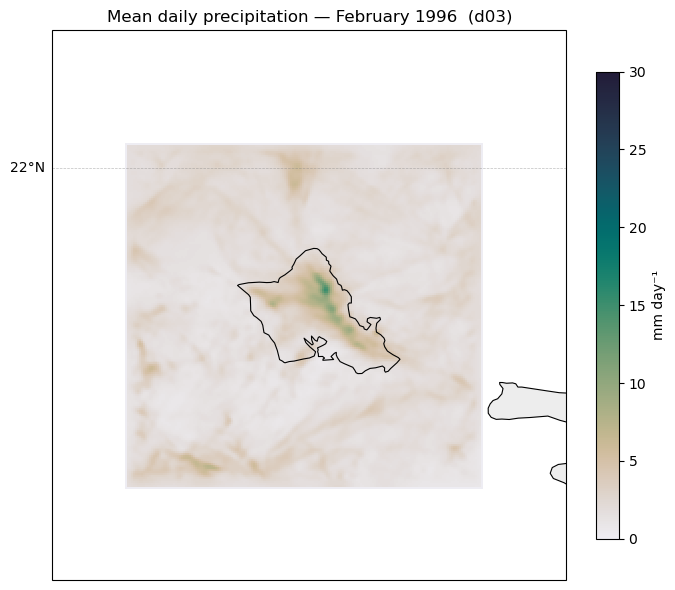

In [97]:
# example: all of February 1996
feb_files = [f for f in files if '1996-02' in f]
print(f'Loading {len(feb_files)} February files…')

ds_feb = xr.open_mfdataset(feb_files, concat_dim='Time', combine='nested')

# mean daily precip: (RAINC+RAINNC+RAINSH) last_hour - first_hour, averaged across days
accum_feb = ds_feb['RAINC'] + ds_feb['RAINNC'] + ds_feb['RAINSH']  # (Time_total, ny, nx)

# reshape to (ndays, 24, ny, nx) then take [last - first] per day
n_times = accum_feb.sizes['Time']
n_days  = n_times // 24
arr = accum_feb.values[:n_days*24].reshape(n_days, 24,
          ds_feb.sizes['south_north'], ds_feb.sizes['west_east'])
daily = arr[:, -1, :, :] - arr[:, 0, :, :]   # (ndays, ny, nx)
mean_precip = daily.mean(axis=0)

# lat/lon from first time step
lat2 = ds_feb['XLAT'].isel(Time=0).values
lon2 = ds_feb['XLONG'].isel(Time=0).values

fig, ax = plot_wrf_2d(
    mean_precip, lat2, lon2,
    title=f'Mean daily precipitation — February 1996  ({DOMAIN})',
    units='mm day⁻¹',
    cmap=cmocean.cm.rain,
    vmin=0, vmax=30,
)
plt.show()